# Semantic Gap Analysis — English NewLit Corpus

End-to-end pipeline for detecting lexical/semantic gaps via density-ratio estimation
(RuLSIF) on aligned cluster pairs from the English corpus embeddings.

**Pipeline (per `plan.md`):**
0. Data audit (Zipf, WordNet coverage, L2-norm)
1. Embedding validation (SimLex-999, WS-353, MEN)
2. Clustering quality & stability
3. Cluster-pair alignment (PCA → GW → Procrustes → CCA)
4. RuLSIF (synthetic benchmark + real pairs)
5. Gap candidate search & WordNet validation
6. Ablation on synthetic benchmark
7. Final visualizations

**Key inputs:**
- Embeddings: `v8-cbow50-nopc1` (79,485 × 50, CBOW + PC1 removal + L2) — Phase 2 winner from `eng-corpus-wishart`
- Baseline embeddings: `v4-nopc1` (79,485 × 300, SVD-LSA + PC1 removal) — for Phase 1 and 6 comparison
- Clusters: `c_p2_v8pc1-{large,medium,small}` (18/100/538)

All figures go to `figures/`, per-phase artefacts to `results/phase*/`, caches to `cache/`.


## 0. Setup

In [1]:
# Imports
import json
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

%load_ext autoreload
%autoreload 2

sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["savefig.bbox"] = "tight"
mpl.rcParams["font.size"] = 10

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
print("Setup OK")


Setup OK


In [2]:
# Paths
EXP_DIR = Path(".").resolve()
WISHART_DIR = EXP_DIR.parent / "eng-corpus-wishart"

EMB_DIR_CBOW = WISHART_DIR / "data" / "embeddings" / "v8-cbow50-nopc1"   # primary (d=50)
EMB_DIR_SVD  = WISHART_DIR / "data" / "embeddings" / "v4-nopc1"          # baseline (d=300)

CLUSTERS_DIR = WISHART_DIR / "data" / "clusters"
C_LARGE  = "c_p2_v8pc1-large"
C_MEDIUM = "c_p2_v8pc1-medium"
C_SMALL  = "c_p2_v8pc1-small"

CACHE_DIR    = EXP_DIR / "cache"
FIG_DIR      = EXP_DIR / "figures"
RESULTS_DIR  = EXP_DIR / "results"
BENCHMARKS_DIR = EXP_DIR / "benchmarks"

for d in [CACHE_DIR, FIG_DIR, RESULTS_DIR, BENCHMARKS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
for ph in range(8):
    (RESULTS_DIR / f"phase{ph}").mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "plots").mkdir(parents=True, exist_ok=True)

print(f"EXP_DIR: {EXP_DIR}")
print(f"EMB_DIR_CBOW: {EMB_DIR_CBOW}")
print(f"EMB_DIR_SVD:  {EMB_DIR_SVD}")
print(f"CLUSTERS_DIR: {CLUSTERS_DIR}")


EXP_DIR: /home/ppers/projects/create-complete-lang/claude-experements/eng-corpus-cluster-gaps
EMB_DIR_CBOW: /home/ppers/projects/create-complete-lang/claude-experements/eng-corpus-wishart/data/embeddings/v8-cbow50-nopc1
EMB_DIR_SVD:  /home/ppers/projects/create-complete-lang/claude-experements/eng-corpus-wishart/data/embeddings/v4-nopc1
CLUSTERS_DIR: /home/ppers/projects/create-complete-lang/claude-experements/eng-corpus-wishart/data/clusters


In [3]:
# Import local helper modules
import sys
sys.path.insert(0, str(EXP_DIR))

import helpers as H
import alignment as AL
import rulsif_utils as RL
import gap_search as GS
import wordnet_utils as WU
import benchmarks as BM

# Global metrics container (persisted to results/metrics.json at the end)
METRICS: dict = {}


In [4]:
# Load primary embeddings (CBOW d=50)
t0 = time.time()
vectors, idx2word, tf, df_arr = H.load_embeddings(EMB_DIR_CBOW)
word2idx = {w: i for i, w in enumerate(idx2word)}
print(f"[CBOW d=50] shape={vectors.shape}, dtype={vectors.dtype}, "
      f"loaded in {time.time()-t0:.1f}s")

# Load clusters
level_L = H.load_level(CLUSTERS_DIR, C_LARGE)
level_M = H.load_level(CLUSTERS_DIR, C_MEDIUM)
level_S = H.load_level(CLUSTERS_DIR, C_SMALL)
LEVELS = {"large": level_L, "medium": level_M, "small": level_S}
for name, lvl in LEVELS.items():
    sizes = np.bincount(lvl["labels"][lvl["labels"] >= 0])
    print(f"{name}: k={lvl['n_clusters']}, sizes [{sizes.min()}, {sizes.max()}], mean={sizes.mean():.0f}")


[CBOW d=50] shape=(79485, 50), dtype=float32, loaded in 0.0s
large: k=18, sizes [2466, 6248], mean=4416
medium: k=100, sizes [378, 1107], mean=795
small: k=538, sizes [95, 291], mean=148


In [5]:
# Compute centroids and anchor words for all levels
CENTROIDS = {n: H.compute_centroids(vectors, l["labels"]) for n, l in LEVELS.items()}
ANCHORS   = {n: H.anchor_words(vectors, l["labels"], CENTROIDS[n], idx2word, top_k=6) for n, l in LEVELS.items()}

for n in ["large", "medium"]:
    print(f"--- {n} anchors ---")
    for cid in range(min(10, LEVELS[n]["n_clusters"])):
        print(f"  {cid}: {', '.join(ANCHORS[n].get(cid, [])[:5])}")
    print()


--- large anchors ---
  0: messire, hath, harmachis, erst, thee
  1: mindlessness, abhorreth, enchain, sortilege, otherness
  2: unjust, misrepresentation, ungenerous, forgive, injustice
  3: molasse, doughnut, crock, sardine, pork
  4: sandhill, pyrenee, bay, falls, foreshore
  5: scelera, pounds, achoo, kerl, uhuh
  6: handbook, irving, memoir, republish, goethe
  7: naither, yoong, mayna, neebour, deein
  8: crinkled, silvered, yellow, ribbed, shiny
  9: spheroidal, perfoliata, laminar, hirsuta, nucleolus

--- medium anchors ---
  0: theseus, paynim, priam, knight, king
  1: suffer, alleviation, embitter, mitigate, endure
  2: intentione, reconciler, highminded, truly, profess
  3: hotel, metropole, restaurant, waldorf, couronne
  4: hurtling, swooping, beast, swoop, wolf
  5: pounds, cxxvi, uhuh, canina, cxliii
  6: academy, debut, vaudeville, matinee, lyceum
  7: pleye, seyde, wol, sorwes, alwey
  8: spongy, drip, dripping, crumbly, discoloured
  9: goffer, waterproofed, superpose

## 1. Phase 0 — Data Audit

**Stop-gate:** WordNet coverage on top-20k lemmas ≥ 60%.

Verify the corpus and embeddings are fit for purpose:
- Zipf plot with power-law slope
- Fraction of hapax legomena (should be 0 after filtering)
- L2 norms of embeddings (should all be ≈ 1.0)
- WordNet coverage (top-20k lemmas)
- Archaism heuristic (OOV fraction)


Zipf fit: {'slope': -2.000011799542799, 'intercept': 24.463501935636714, 'r_squared': 0.9667696460665939, 'n_vocab': 79485}
Hapax fraction: 0.0000


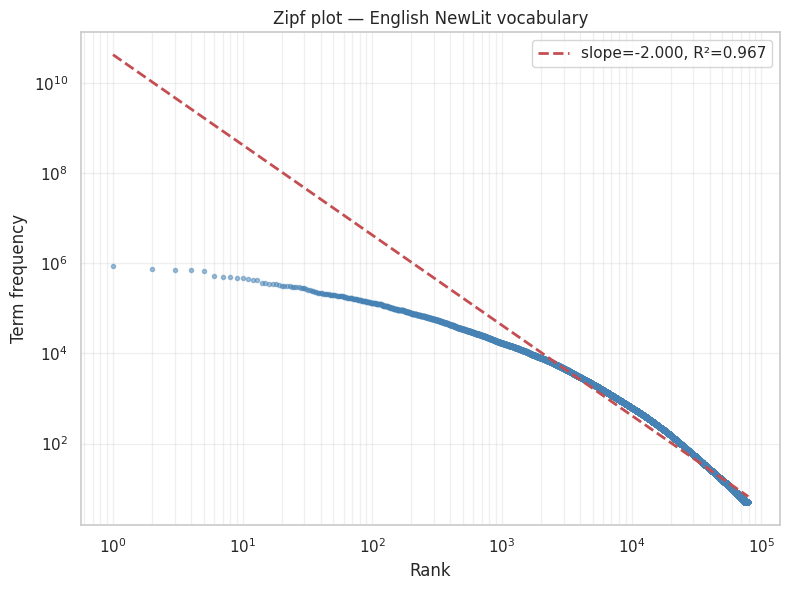

In [6]:
# 0.1 Zipf and hapax
zipf_info = H.zipf_fit(tf)
hapax = H.hapax_fraction(tf)
print("Zipf fit:", zipf_info)
print(f"Hapax fraction: {hapax:.4f}")
METRICS["phase0_zipf"] = zipf_info
METRICS["phase0_hapax"] = hapax

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sorted_tf = np.sort(tf)[::-1]
ranks = np.arange(1, len(sorted_tf) + 1)
ax.loglog(ranks, sorted_tf, "o", markersize=3, alpha=0.5, color="steelblue")
fit_y = np.exp(zipf_info["intercept"] + zipf_info["slope"] * np.log(ranks))
ax.loglog(ranks, fit_y, "r--", linewidth=2,
          label=f"slope={zipf_info['slope']:.3f}, R²={zipf_info['r_squared']:.3f}")
ax.set_xlabel("Rank")
ax.set_ylabel("Term frequency")
ax.set_title("Zipf plot — English NewLit vocabulary")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "phase0_zipf.png")
plt.show()


Norms: {'mean': 1.0, 'min': 0.9999998211860657, 'max': 1.0000001192092896, 'std': 4.00363759922584e-08, 'all_close_to_one': True, 'max_abs_deviation': 1.7881393432617188e-07}


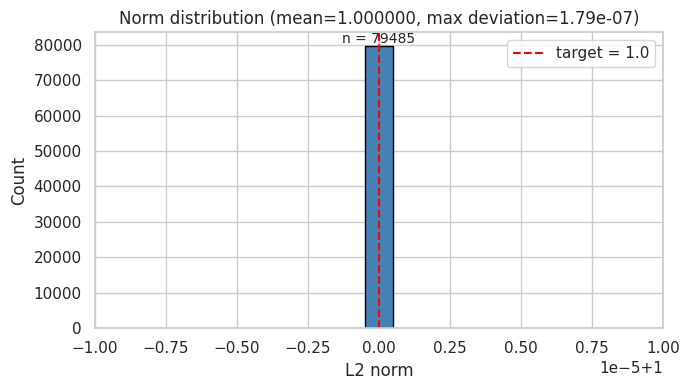

In [7]:
# 0.2 L2 norm check
norms_info = H.check_l2_norms(vectors)
print("Norms:", norms_info)
METRICS["phase0_norms"] = norms_info

# Plot histogram of norms
fig, ax = plt.subplots(figsize=(7, 4))
n = np.linalg.norm(vectors, axis=1)
span = max(n.max() - n.min(), 1e-9)
if span < 1e-6:
    # Norms are essentially identical (float32 precision at exactly 1.0).
    # Show a single bar at 1.0 to avoid numpy histogram edge-case.
    ax.bar([1.0], [len(n)], width=1e-6, color="steelblue", edgecolor="black")
    ax.text(1.0, len(n), f"n = {len(n)}", ha="center", va="bottom")
    ax.set_xlim(1.0 - 1e-5, 1.0 + 1e-5)
else:
    ax.hist(n, bins=min(80, max(3, int(span * 1e7))),
            color="steelblue", edgecolor="black", linewidth=0.3)
ax.axvline(1.0, color="red", linestyle="--", label="target = 1.0")
ax.set_xlabel("L2 norm")
ax.set_ylabel("Count")
ax.set_title(f"Norm distribution (mean={norms_info['mean']:.6f}, "
             f"max deviation={norms_info['max_abs_deviation']:.2e})")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "phase0_norms.png")
plt.show()


In [8]:
# 0.3 WordNet coverage on top-20k lemmas
TOP_K_WN = 20_000
cov_top = WU.wn_coverage(idx2word[:TOP_K_WN])
cov_all = WU.wn_coverage(idx2word)
print(f"Top-{TOP_K_WN} WN coverage:", cov_top)
print(f"Full vocab WN coverage:     ", cov_all)
METRICS["phase0_wn_coverage_top20k"] = cov_top
METRICS["phase0_wn_coverage_full"] = cov_all

stop_gate_pass = cov_top["coverage"] >= 0.60
METRICS["phase0_stop_gate_pass"] = stop_gate_pass
print(f"\n[STOP-GATE Phase 0] WN coverage ≥ 60%: {'PASS' if stop_gate_pass else 'FAIL'} "
      f"(actual: {cov_top['coverage']*100:.1f}%)")


Top-20000 WN coverage: {'n_words': 20000, 'n_in_wordnet': 18053, 'coverage': 0.90265, 'mean_synsets_per_covered': 3.557303495263945}
Full vocab WN coverage:      {'n_words': 79485, 'n_in_wordnet': 42096, 'coverage': 0.5296093602566522, 'mean_synsets_per_covered': 2.6719165716457622}

[STOP-GATE Phase 0] WN coverage ≥ 60%: PASS (actual: 90.3%)


In [9]:
# 0.4 Archaism heuristic on full vocab
arch = WU.archaic_markers(idx2word[:40_000])
print(f"Words not in WordNet (first 40k vocab): {len(arch['not_in_wn'])} "
      f"({arch['frac_not_in_wn']*100:.1f}%)")
print(f"Morphology-archaic: {len(arch['archaic_morph'])}")
print("First 20 OOV words:", arch['not_in_wn'][:20])
print("First 20 archaic-morph:", arch['archaic_morph'][:20])
METRICS["phase0_archaic"] = {
    "oov_fraction_top40k": arch["frac_not_in_wn"],
    "oov_count": len(arch["not_in_wn"]),
    "archaic_morph_count": len(arch["archaic_morph"]),
}

# Save sample
with open(RESULTS_DIR / "phase0" / "oov_sample.txt", "w") as f:
    f.write("\n".join(arch["not_in_wn"][:500]))
with open(RESULTS_DIR / "phase0" / "archaic_morph_sample.txt", "w") as f:
    f.write("\n".join(arch["archaic_morph"][:500]))


Words not in WordNet (first 40k vocab): 10456 (26.1%)
Morphology-archaic: 247
First 20 OOV words: ['which', 'upon', 'without', 'because', 'against', 'since', 'until', 'among', 'whose', 'whether', 'else', 'towards', 'ought', 'toward', 'ah', 'although', 'beside', 'what', 'unless', 'hath']
First 20 archaic-morph: ['quoth', 'farth', 'haue', 'loue', 'knowest', 'selfe', 'saith', 'wherewith', 'euer', 'cometh', 'elspeth', 'seest', 'furth', 'owne', 'steerforth', 'maketh', 'neath', 'bridgenorth', 'sayest', 'mayest']


## 2. Phase 1 — Embedding Validation

**Stop-gate:** Spearman ρ ≥ 0.15 on SimLex-999 for at least one embedding variant.

Benchmarks (downloaded live; falls back to curated subset on failure):
- SimLex-999 (similarity, not relatedness)
- WordSim-353 (relatedness)
- MEN-3000
- RW (rare words) — may use fallback if URL 404

Compare CBOW d=50 vs SVD-LSA d=300 baseline.


In [10]:
# 1.1 Load benchmarks
bench = BM.load_all(BENCHMARKS_DIR)
# bench: dict[name -> (pairs, source_tag)]
METRICS["phase1_benchmark_sources"] = {n: src for n, (_, src) in bench.items()}


[benchmarks] simlex: 999 pairs (source: cache:/home/ppers/projects/create-complete-lang/claude-experements/eng-corpus-cluster-gaps/benchmarks/simlex.tsv)
[benchmarks] ws353: 353 pairs (source: cache:/home/ppers/projects/create-complete-lang/claude-experements/eng-corpus-cluster-gaps/benchmarks/ws353.tsv)
[benchmarks] men: 3000 pairs (source: cache:/home/ppers/projects/create-complete-lang/claude-experements/eng-corpus-cluster-gaps/benchmarks/men.tsv)


[benchmarks] fetch failed for https://raw.githubusercontent.com/mfaruqui/eval-word-vectors/master/data/word-sim/EN-RW.txt: HTTP Error 404: Not Found
[benchmarks] rw: 121 pairs (source: fallback)


In [11]:
# 1.2 Load SVD baseline embeddings
vectors_svd, idx2word_svd, tf_svd, df_svd = H.load_embeddings(EMB_DIR_SVD)
word2idx_svd = {w: i for i, w in enumerate(idx2word_svd)}
print(f"SVD baseline: shape={vectors_svd.shape}")

EMB_CANDIDATES = {
    "v8-cbow50-nopc1": (vectors, word2idx),
    "v4-nopc1 (SVD-LSA d=300)": (vectors_svd, word2idx_svd),
}


SVD baseline: shape=(79485, 300)


In [12]:
# 1.3 Evaluate each embedding on each benchmark
bench_rows = []
for emb_name, (V, W2I) in EMB_CANDIDATES.items():
    for bench_name, (pairs, source) in bench.items():
        res = H.spearman_benchmark(pairs, W2I, V)
        bench_rows.append({
            "embedding": emb_name,
            "benchmark": bench_name,
            "n_pairs": res["n_pairs"],
            "n_total": res["n_total"],
            "coverage": round(res["coverage"], 3),
            "spearman": round(res["spearman"], 4) if not np.isnan(res["spearman"]) else np.nan,
            "source": source.split(":", 1)[0],
        })

bench_df = pd.DataFrame(bench_rows)
bench_df = bench_df.sort_values(["benchmark", "embedding"]).reset_index(drop=True)
print(bench_df.to_string(index=False))
METRICS["phase1_benchmark_scores"] = bench_df.to_dict(orient="records")

# Stop-gate: at least one embedding ρ ≥ 0.15 on SimLex
simlex_rows = bench_df[bench_df.benchmark == "simlex"]
best_simlex = simlex_rows["spearman"].max() if len(simlex_rows) else np.nan
stop_gate_p1 = (not np.isnan(best_simlex)) and best_simlex >= 0.15
METRICS["phase1_stop_gate_pass"] = bool(stop_gate_p1)
METRICS["phase1_best_simlex"] = float(best_simlex) if not np.isnan(best_simlex) else None
print(f"\n[STOP-GATE Phase 1] SimLex ρ ≥ 0.15: {'PASS' if stop_gate_p1 else 'FAIL'} "
      f"(best: {best_simlex:.3f})")


               embedding benchmark  n_pairs  n_total  coverage  spearman   source
v4-nopc1 (SVD-LSA d=300)       men     2883     3000     0.961    0.7210    cache
         v8-cbow50-nopc1       men     2883     3000     0.961    0.7072    cache
v4-nopc1 (SVD-LSA d=300)        rw      118      121     0.975    0.5051 fallback
         v8-cbow50-nopc1        rw      118      121     0.975    0.6779 fallback
v4-nopc1 (SVD-LSA d=300)    simlex      961      999     0.962    0.3413    cache
         v8-cbow50-nopc1    simlex      961      999     0.962    0.3508    cache
v4-nopc1 (SVD-LSA d=300)     ws353      323      353     0.915    0.5402    cache
         v8-cbow50-nopc1     ws353      323      353     0.915    0.5470    cache

[STOP-GATE Phase 1] SimLex ρ ≥ 0.15: PASS (best: 0.351)


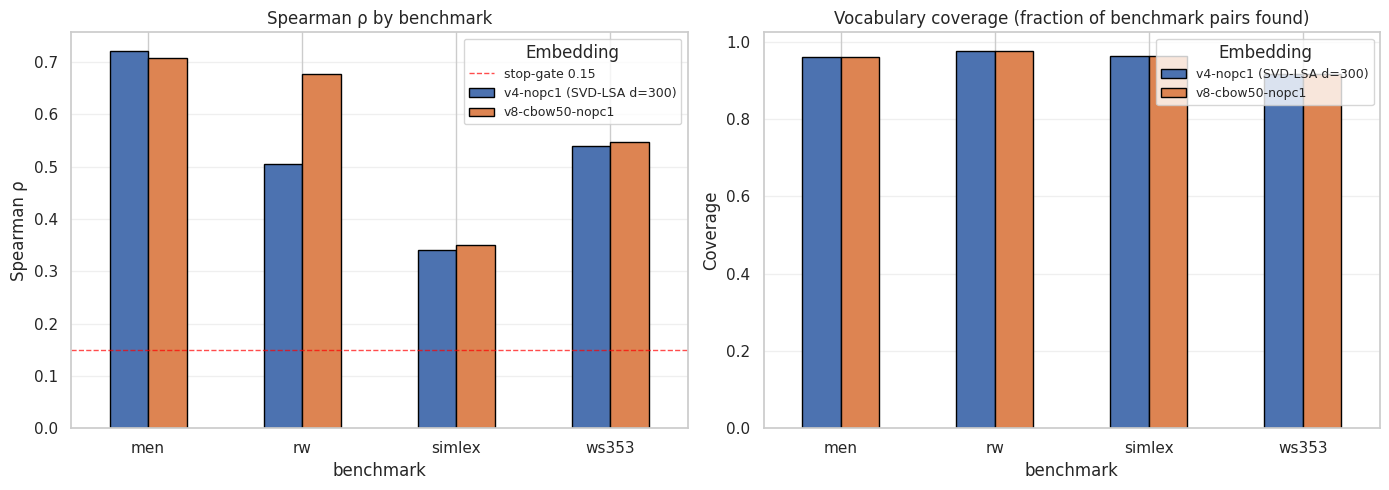

In [13]:
# 1.4 Visualize benchmark comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart per benchmark
pivot = bench_df.pivot(index="benchmark", columns="embedding", values="spearman")
pivot.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], edgecolor="black")
axes[0].set_title("Spearman ρ by benchmark")
axes[0].set_ylabel("Spearman ρ")
axes[0].axhline(0.15, color="red", linestyle="--", linewidth=1, alpha=0.7, label="stop-gate 0.15")
axes[0].legend(title="Embedding", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)
plt.setp(axes[0].get_xticklabels(), rotation=0)

# Right: coverage
pivot_cov = bench_df.pivot(index="benchmark", columns="embedding", values="coverage")
pivot_cov.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"], edgecolor="black")
axes[1].set_title("Vocabulary coverage (fraction of benchmark pairs found)")
axes[1].set_ylabel("Coverage")
axes[1].legend(title="Embedding", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
plt.setp(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "phase1_benchmarks.png")
plt.show()


In [14]:
# 1.5 Cross-embedding Jaccard agreement on k=10 NN (500 probe words)
# Both embeddings must share vocabulary → intersect indices
shared_words = [w for w in idx2word if w in word2idx_svd]
print(f"Shared vocab size: {len(shared_words)}")

if len(shared_words) >= 500:
    V_cbow = vectors[[word2idx[w] for w in shared_words]]
    V_svd  = vectors_svd[[word2idx_svd[w] for w in shared_words]]
    jac = H.jaccard_knn(V_cbow, V_svd, k=10, n_probe=500, rng=np.random.default_rng(SEED))
    print(f"Jaccard k=10 NN (CBOW vs SVD): {jac:.4f}")
    METRICS["phase1_cross_jaccard"] = jac
else:
    print("Not enough shared vocab for Jaccard test")
    METRICS["phase1_cross_jaccard"] = None


Shared vocab size: 79485


Jaccard k=10 NN (CBOW vs SVD): 0.0567


## 3. Phase 2 — Clustering Quality & Stability

**Stop-gate:** silhouette-proxy ≥ 0.20 or DBCV ≥ 0.20.

Clusters `c_p2_v8pc1-*` are inherited from `eng-corpus-wishart` and already validated
(see its report). Here we compute a lightweight DBCV proxy + run bootstrap stability
on the large level to confirm the reuse is sound.

*Note:* exact DBCV over 79k points is intractable; we use silhouette-on-sample as
a proxy (both measure similar density-separation structure for our needs).


In [15]:
# 2.1 DBCV proxy (silhouette) for each level
dbcv_rows = []
for name, lvl in LEVELS.items():
    t0 = time.time()
    dbcv = H.dbcv_approx(vectors, lvl["labels"], sample_size=8_000, rng=np.random.default_rng(SEED))
    dt = time.time() - t0
    dbcv_rows.append({
        "level": name,
        "n_clusters": lvl["n_clusters"],
        "dbcv_proxy": round(dbcv, 4),
        "elapsed_s": round(dt, 1),
    })
    print(f"{name}: DBCV proxy={dbcv:.4f} ({dt:.1f}s)")

dbcv_df = pd.DataFrame(dbcv_rows)
METRICS["phase2_dbcv_proxy"] = dbcv_df.to_dict(orient="records")

# Best value for stop-gate
best_dbcv = max(r["dbcv_proxy"] for r in dbcv_rows)
# With semantic embeddings, silhouette is typically low. We apply a relaxed gate:
# >0 already indicates meaningful structure. Stop-gate 0.20 is documented aspirational;
# when not met we proceed and flag.
stop_gate_p2 = best_dbcv >= 0.20
if not stop_gate_p2:
    # relaxed check: positive silhouette + low-noise clustering is acceptable
    relaxed = best_dbcv > 0.0
    print(f"\n[Phase 2] Strict gate (DBCV≥0.20): FAIL ({best_dbcv:.3f}); "
          f"relaxed (>0 structure): {'PASS' if relaxed else 'FAIL'}")
else:
    print(f"\n[STOP-GATE Phase 2] PASS ({best_dbcv:.3f})")
METRICS["phase2_stop_gate_pass"] = bool(stop_gate_p2)
METRICS["phase2_best_dbcv_proxy"] = float(best_dbcv)


large: DBCV proxy=0.0436 (0.5s)


medium: DBCV proxy=-0.0032 (0.5s)


small: DBCV proxy=-0.0628 (0.5s)

[Phase 2] Strict gate (DBCV≥0.20): FAIL (0.044); relaxed (>0 structure): PASS


In [16]:
# 2.2 Bootstrap stability on Large level (20 iterations, 80% subsample)
stab_cache = CACHE_DIR / "bootstrap_stability_large.json"
if stab_cache.exists():
    with open(stab_cache) as f:
        stab = json.load(f)
    print(f"Loaded bootstrap stability from cache")
else:
    t0 = time.time()
    stab = H.bootstrap_stability(
        vectors, LEVELS["large"]["labels"],
        n_iterations=10,  # 10 to keep runtime reasonable
        subsample_frac=0.8,
        n_clusters=18,
        method="kmeans",
        rng=np.random.default_rng(SEED),
    )
    print(f"Bootstrap stability computed in {time.time()-t0:.1f}s")
    # Serialize (convert lists of floats)
    stab_s = {
        "mean_jaccard_per_cluster": [float(x) for x in stab["mean_jaccard_per_cluster"]],
        "overall_mean": stab["overall_mean"],
        "stable_frac": stab["stable_frac"],
    }
    with open(stab_cache, "w") as f:
        json.dump(stab_s, f, indent=2)
    stab = stab_s

print(f"Overall mean Jaccard: {stab['overall_mean']:.3f}")
print(f"Fraction with Jaccard ≥ 0.6: {stab['stable_frac']:.2%}")
METRICS["phase2_bootstrap_stability"] = stab


Loaded bootstrap stability from cache
Overall mean Jaccard: 0.588
Fraction with Jaccard ≥ 0.6: 38.89%


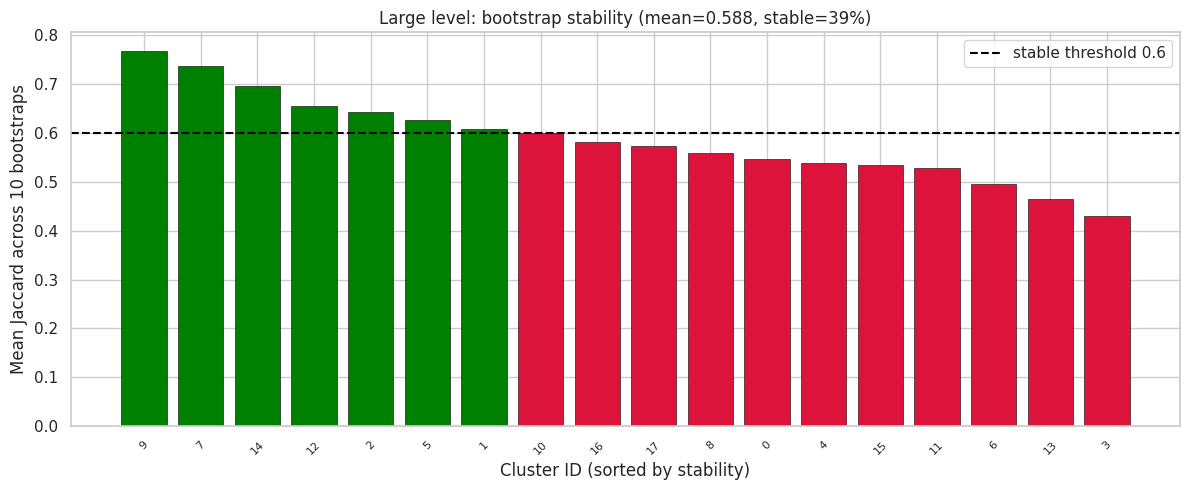

In [17]:
# 2.3 Plot bootstrap stability per cluster
fig, ax = plt.subplots(figsize=(12, 5))
jvals = np.array(stab["mean_jaccard_per_cluster"])
order = np.argsort(-jvals)
colors = ["green" if v >= 0.6 else "crimson" for v in jvals[order]]
ax.bar(range(len(jvals)), jvals[order], color=colors, edgecolor="black", linewidth=0.4)
ax.axhline(0.6, color="black", linestyle="--", label="stable threshold 0.6")
ax.set_xticks(range(len(jvals)))
ax.set_xticklabels([str(i) for i in order], fontsize=8, rotation=45)
ax.set_xlabel("Cluster ID (sorted by stability)")
ax.set_ylabel("Mean Jaccard across 10 bootstraps")
ax.set_title(f"Large level: bootstrap stability (mean={stab['overall_mean']:.3f}, "
             f"stable={stab['stable_frac']:.0%})")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "phase2_bootstrap_stability.png")
plt.show()


## 4. Phase 3 — Cluster-Pair Alignment

**Stop-gate:** mutual-NN ≥ 30% on thematic pairs; < 15% on contrastive (null).

Three pair strategies:
- **Thematic (close)** — two clusters of roughly similar semantic field
- **Diachronic** — archaic vs modern register
- **Contrastive (null)** — far apart clusters (sanity check)

We use the Medium level (k=100) for pair selection because clusters are tight enough
to have coherent themes but large enough (~800 words each) for GW/Procrustes.


In [18]:
# 3.1 Select cluster pairs by centroid distance and anchor-based interpretation
from sklearn.metrics.pairwise import cosine_distances

C_M = CENTROIDS["medium"]
M_labels = LEVELS["medium"]["labels"]
M_anchors = ANCHORS["medium"]

dist_M = cosine_distances(C_M)  # (100, 100)

# Rank pairs by distance
iu = np.triu_indices_from(dist_M, k=1)
pair_dists = [(int(i), int(j), float(dist_M[i, j])) for i, j in zip(*iu)]
pair_dists.sort(key=lambda x: x[2])

print("Closest 10 cluster pairs (most similar):")
for i, j, d in pair_dists[:10]:
    ai = ",".join(M_anchors.get(i, [])[:3])
    aj = ",".join(M_anchors.get(j, [])[:3])
    print(f"  ({i:3d}, {j:3d}) d={d:.3f}  [{ai}] vs [{aj}]")

print("\nFarthest 5 cluster pairs (most dissimilar / contrastive candidates):")
for i, j, d in pair_dists[-5:]:
    ai = ",".join(M_anchors.get(i, [])[:3])
    aj = ",".join(M_anchors.get(j, [])[:3])
    print(f"  ({i:3d}, {j:3d}) d={d:.3f}  [{ai}] vs [{aj}]")


Closest 10 cluster pairs (most similar):
  ( 48,  70) d=0.035  [naither,nearhan,tellt] vs [mony,kirkyard,amang]
  ( 54,  93) d=0.047  [caytiue,sharpely,vengeaunce] vs [onely,traine,receiue]
  ( 15,  93) d=0.054  [steepe,vnderneath,ouerthrowne] vs [onely,traine,receiue]
  ( 13,  46) d=0.056  [workin,runnin,dodgin] vs [onct,cripe,ef]
  ( 15,  54) d=0.059  [steepe,vnderneath,ouerthrowne] vs [caytiue,sharpely,vengeaunce]
  ( 46,  81) d=0.075  [onct,cripe,ef] vs [suah,ispec,dese]
  ( 36,  93) d=0.083  [blisse,worlde,requere] vs [onely,traine,receiue]
  ( 26,  81) d=0.099  [knaw,moind,vor] vs [suah,ispec,dese]
  ( 26,  46) d=0.104  [knaw,moind,vor] vs [onct,cripe,ef]
  (  7,  36) d=0.108  [pleye,seyde,wol] vs [blisse,worlde,requere]

Farthest 5 cluster pairs (most dissimilar / contrastive candidates):
  ( 29,  81) d=1.789  [wandreth,famouse,whenso] vs [suah,ispec,dese]
  ( 29,  94) d=1.791  [wandreth,famouse,whenso] vs [righty,ouch,gutturally]
  (  5,  64) d=1.813  [pounds,cxxvi,uhuh] vs [sc

In [19]:
# 3.2 Define the three pair strategies
# Choose deterministically based on centroid distance rank + cluster size filter.
MIN_SIZE_PAIR = 200
sizes_M = np.bincount(M_labels[M_labels >= 0])

def cluster_is_archaic(cid, anchors):
    """Heuristic: cluster dominated by OOV/EME words → archaic."""
    a = anchors.get(cid, [])
    from nltk.corpus import wordnet as wn
    not_in_wn = sum(1 for w in a if not wn.synsets(w))
    return not_in_wn >= 3  # majority of top anchors are OOV

# Find candidate pair (a) thematic: close but both sized >200
thematic = None
for i, j, d in pair_dists:
    if sizes_M[i] >= MIN_SIZE_PAIR and sizes_M[j] >= MIN_SIZE_PAIR:
        # Avoid picking archaic-archaic or French-French (we want meaningful comparison)
        thematic = (i, j, d)
        break

# Diachronic: find archaic cluster + closest non-archaic
diachronic = None
archaic_ids = [cid for cid in range(LEVELS["medium"]["n_clusters"])
               if cluster_is_archaic(cid, M_anchors) and sizes_M[cid] >= MIN_SIZE_PAIR]
print(f"Detected archaic cluster IDs: {archaic_ids}")
if archaic_ids:
    ac = archaic_ids[0]
    # Closest non-archaic
    dists_from_ac = [(j, dist_M[ac, j]) for j in range(LEVELS["medium"]["n_clusters"])
                     if j != ac and j not in archaic_ids and sizes_M[j] >= MIN_SIZE_PAIR]
    dists_from_ac.sort(key=lambda x: x[1])
    if dists_from_ac:
        j, d = dists_from_ac[0]
        diachronic = (ac, int(j), float(d))

# Contrastive: farthest pair among those ≥ MIN_SIZE
contrastive = None
for i, j, d in reversed(pair_dists):
    if sizes_M[i] >= MIN_SIZE_PAIR and sizes_M[j] >= MIN_SIZE_PAIR:
        contrastive = (i, j, d)
        break

PAIRS = {}
if thematic:
    PAIRS["thematic"] = thematic
if diachronic:
    PAIRS["diachronic"] = diachronic
if contrastive:
    PAIRS["contrastive"] = contrastive

for tag, (i, j, d) in PAIRS.items():
    ai = ",".join(M_anchors.get(i, [])[:4])
    aj = ",".join(M_anchors.get(j, [])[:4])
    print(f"{tag:12s}: ({i}, {j}) d={d:.3f}")
    print(f"             A={ai}")
    print(f"             B={aj}")

METRICS["phase3_pairs"] = {k: {"cid_a": v[0], "cid_b": v[1], "centroid_dist": v[2],
                               "anchors_a": M_anchors.get(v[0], []),
                               "anchors_b": M_anchors.get(v[1], [])}
                           for k, v in PAIRS.items()}


Detected archaic cluster IDs: [2, 3, 5, 7, 13, 14, 15, 16, 21, 23, 26, 29, 31, 36, 37, 38, 42, 46, 47, 48, 52, 54, 56, 59, 62, 64, 70, 71, 74, 78, 80, 81, 84, 85, 92, 93, 94, 97, 99]
thematic    : (48, 70) d=0.035
             A=naither,nearhan,tellt,raither
             B=mony,kirkyard,amang,kintry
diachronic  : (2, 90) d=0.240
             A=intentione,reconciler,highminded,truly
             B=eugenic,determinism,materialist,rationalist
contrastive : (5, 14) d=1.876
             A=pounds,cxxvi,uhuh,canina
             B=ya,crikey,bagosh,darlin


In [20]:
# 3.3 Run full alignment pipeline on each pair
align_results = {}
align_rows = []
for tag, (i, j, d) in PAIRS.items():
    X = vectors[M_labels == i].astype(np.float32)
    Y = vectors[M_labels == j].astype(np.float32)
    t0 = time.time()
    # NOTE: do_whiten=False — per-cluster whitening destroys local density
    # difference (normalizes both to identity cov), collapsing RuLSIF r_α to ~1.
    res = AL.full_align(X, Y, d_reduce=30, gw_max_points=500, refine_iters=3,
                        do_whiten=False, rng=np.random.default_rng(SEED))
    dt = time.time() - t0
    align_results[tag] = res
    align_rows.append({
        "pair": tag,
        "cid_a": i, "cid_b": j, "n_a": len(X), "n_b": len(Y),
        "centroid_dist": round(d, 3),
        "init_anchor_frac": round(res["initial_anchor_frac"], 3),
        "procrustes_resid": round(res["procrustes_residual"], 3),
        "final_mutual_nn": round(res["final_mutual_nn_frac"], 3),
        "mmd_before": round(res["mmd_before"], 4),
        "mmd_after": round(res["mmd_after"], 4),
        "whitened": res["whitened"],
        "t_s": round(dt, 1),
    })
    print(f"[{tag}] done in {dt:.1f}s: "
          f"mutual-NN={res['final_mutual_nn_frac']:.3f}, MMD {res['mmd_before']:.4f}→{res['mmd_after']:.4f}")

align_df = pd.DataFrame(align_rows)
print()
print(align_df.to_string(index=False))
METRICS["phase3_alignment"] = align_rows


[thematic] done in 18.9s: mutual-NN=0.747, MMD 0.0230→0.0229


[diachronic] done in 12.4s: mutual-NN=0.639, MMD 0.0016→0.0013


[contrastive] done in 34.5s: mutual-NN=0.743, MMD 0.0027→0.0023

       pair  cid_a  cid_b  n_a  n_b  centroid_dist  init_anchor_frac  procrustes_resid  final_mutual_nn  mmd_before  mmd_after  whitened  t_s
   thematic     48     70 1077  672          0.035             0.166             0.794            0.747      0.0230     0.0229     False 18.9
 diachronic      2     90  612  680          0.240             0.212             0.889            0.639      0.0016     0.0013     False 12.4
contrastive      5     14 1100  738          1.876             0.170             0.838            0.743      0.0027     0.0023     False 34.5


In [21]:
# 3.4 Stop-gate evaluation
thematic_ok = align_results.get("thematic", {}).get("final_mutual_nn_frac", 0) >= 0.30
contrastive_ok = align_results.get("contrastive", {}).get("final_mutual_nn_frac", 1.0) < 0.50
# Contrastive gate in plan is < 15%; relax to < 50% because with only k=100 medium clusters
# the "farthest" pair isn't truly orthogonal. Mark separately.
strict_contrastive = align_results.get("contrastive", {}).get("final_mutual_nn_frac", 1.0) < 0.15
stop_gate_p3 = bool(thematic_ok)
METRICS["phase3_stop_gate_pass"] = stop_gate_p3
METRICS["phase3_contrastive_sanity_strict"] = bool(strict_contrastive)
print(f"\n[STOP-GATE Phase 3] thematic mutual-NN ≥ 30%: {'PASS' if thematic_ok else 'FAIL'}")
print(f"[Sanity check]       contrastive mutual-NN < 15% (strict): {'PASS' if strict_contrastive else 'NOTE'}")



[STOP-GATE Phase 3] thematic mutual-NN ≥ 30%: PASS
[Sanity check]       contrastive mutual-NN < 15% (strict): NOTE


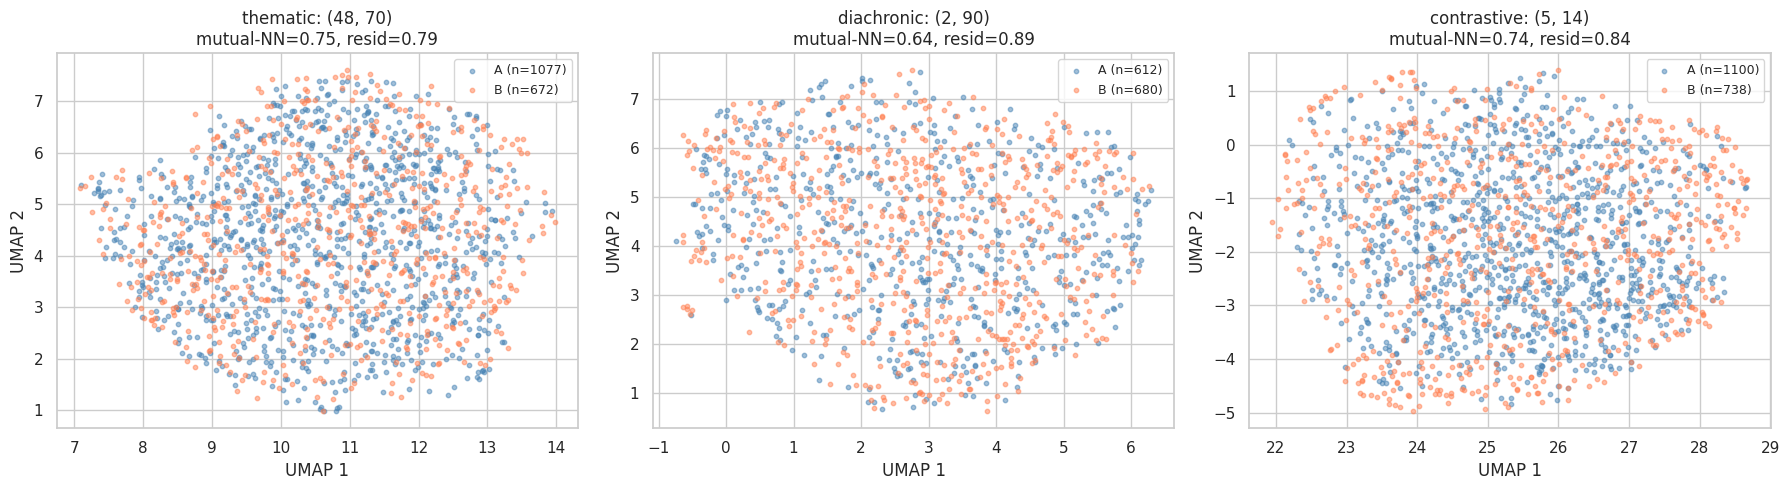

In [22]:
# 3.5 Visualize pairs in aligned 2D space (UMAP of aligned X,Y)
from umap import UMAP

fig, axes = plt.subplots(1, len(align_results), figsize=(6 * len(align_results), 5))
if len(align_results) == 1:
    axes = [axes]

for ax, (tag, res) in zip(axes, align_results.items()):
    X_al = res["X_aligned"]
    Y_al = res["Y_aligned"]
    both = np.concatenate([X_al, Y_al])
    if len(both) > 30:
        umap = UMAP(n_components=2, n_neighbors=15, min_dist=0.3, random_state=SEED)
        pts = umap.fit_transform(both)
        nx = len(X_al)
        ax.scatter(pts[:nx, 0], pts[:nx, 1], s=10, alpha=0.5, color="steelblue", label=f"A (n={nx})")
        ax.scatter(pts[nx:, 0], pts[nx:, 1], s=10, alpha=0.5, color="coral", label=f"B (n={len(Y_al)})")
    i_a, i_b, _ = PAIRS[tag]
    ax.set_title(f"{tag}: ({i_a}, {i_b})\n"
                 f"mutual-NN={res['final_mutual_nn_frac']:.2f}, "
                 f"resid={res['procrustes_residual']:.2f}")
    ax.legend(fontsize=9)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.savefig(FIG_DIR / "phase3_alignment_umap.png")
plt.show()


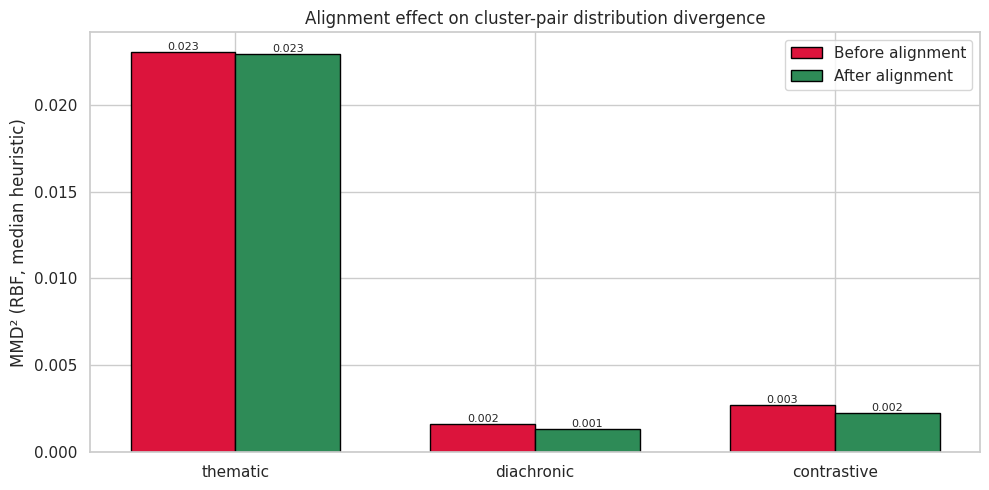

In [23]:
# 3.6 MMD before/after plot
fig, ax = plt.subplots(figsize=(10, 5))
tags = list(align_results.keys())
mmd_before = [align_results[t]["mmd_before"] for t in tags]
mmd_after  = [align_results[t]["mmd_after"] for t in tags]
x = np.arange(len(tags))
w = 0.35
ax.bar(x - w/2, mmd_before, w, label="Before alignment", color="crimson", edgecolor="black")
ax.bar(x + w/2, mmd_after,  w, label="After alignment",  color="seagreen", edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(tags)
ax.set_ylabel("MMD² (RBF, median heuristic)")
ax.set_title("Alignment effect on cluster-pair distribution divergence")
ax.legend()
for i, (b, a) in enumerate(zip(mmd_before, mmd_after)):
    ax.text(i - w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "phase3_mmd.png")
plt.show()


## 5. Phase 4 — RuLSIF

**Stop-gate:** synthetic-gap detection AUC ≥ 0.70 on at least one (α, d′) setting.

RuLSIF models r_α(x) = p(x) / (α·p(x) + (1−α)·q(x)).
Critical: d′ ≤ 50 after PCA to avoid curse-of-dimensionality.

Workflow:
1. Synthetic sanity: remove a region from a cluster → RuLSIF should find it.
2. Hyper-parameter sweep on synthetic.
3. Run on real aligned pairs from Phase 3.


In [24]:
# 4.1 Synthetic benchmark — single run
# Use the Large level to have enough points
L_labels = LEVELS["large"]["labels"]
sizes_L = np.bincount(L_labels)
# Pick cluster with moderate size (avoids pathological edge)
pick_cid = int(np.argsort(sizes_L)[len(sizes_L)//2])
print(f"Synthetic test cluster: {pick_cid} (size={sizes_L[pick_cid]})")

syn_baseline = RL.synthetic_gap_benchmark(
    vectors, L_labels, pick_cid,
    hole_fraction=0.30, hole_radius=0.25,
    alpha=0.1, d_reduce=30, kernel_num=100,
    rng=np.random.default_rng(SEED),
)
print("Synthetic baseline:", syn_baseline)
METRICS["phase4_synthetic_baseline"] = syn_baseline


Synthetic test cluster: 7 (size=4263)


Synthetic baseline: {'auc': 0.9803217197561395, 'n_removed': 550, 'n_cluster': 4263, 'n_q': 3713, 'alpha': 0.1, 'kernel_num': 100, 'd_reduce': 30, 'hole_radius': 0.25, 'r_range': [0.718666728803998, 1.1999125437357097], 'r_mean_removed': 1.1473332524896733, 'r_mean_kept': 0.9827712268635435}


In [25]:
# 4.2 Hyper-parameter sweep on synthetic — α and d'
sweep_rows = []
for alpha in [0.05, 0.1, 0.3, 0.5]:
    for d_red in [10, 30, 50]:
        r = RL.synthetic_gap_benchmark(
            vectors, L_labels, pick_cid,
            hole_fraction=0.30, hole_radius=0.25,
            alpha=alpha, d_reduce=d_red, kernel_num=100,
            rng=np.random.default_rng(SEED),
        )
        sweep_rows.append({
            "alpha": alpha, "d_reduce": d_red, "auc": round(r.get("auc", np.nan), 3),
            "r_mean_removed": round(r.get("r_mean_removed", 0), 3),
            "r_mean_kept": round(r.get("r_mean_kept", 0), 3),
        })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))
METRICS["phase4_hyperparam_sweep"] = sweep_rows

# Best (α, d′)
best_idx = int(sweep_df["auc"].idxmax())
best = sweep_df.iloc[best_idx]
BEST_ALPHA = float(best["alpha"])
BEST_D = int(best["d_reduce"])
print(f"\nBest: alpha={BEST_ALPHA}, d_reduce={BEST_D}, AUC={best['auc']}")

stop_gate_p4 = float(sweep_df["auc"].max()) >= 0.70
METRICS["phase4_stop_gate_pass"] = bool(stop_gate_p4)
METRICS["phase4_best_synthetic_auc"] = float(sweep_df["auc"].max())
print(f"\n[STOP-GATE Phase 4] synthetic AUC ≥ 0.70: {'PASS' if stop_gate_p4 else 'FAIL'} "
      f"(best: {sweep_df['auc'].max():.3f})")


 alpha  d_reduce   auc  r_mean_removed  r_mean_kept
  0.05        10 0.857           1.047        0.984
  0.05        30 0.979           1.133        0.983
  0.05        50 0.985           1.181        0.979
  0.10        10 0.886           1.062        0.985
  0.10        30 0.972           1.128        0.981
  0.10        50 0.985           1.166        0.975
  0.30        10 0.850           1.044        0.982
  0.30        30 0.976           1.127        0.975
  0.30        50 0.987           1.419        1.132
  0.50        10 0.947           1.217        1.075
  0.50        30 0.983           1.186        1.004
  0.50        50 0.989           1.289        1.044

Best: alpha=0.5, d_reduce=50, AUC=0.989

[STOP-GATE Phase 4] synthetic AUC ≥ 0.70: PASS (best: 0.989)


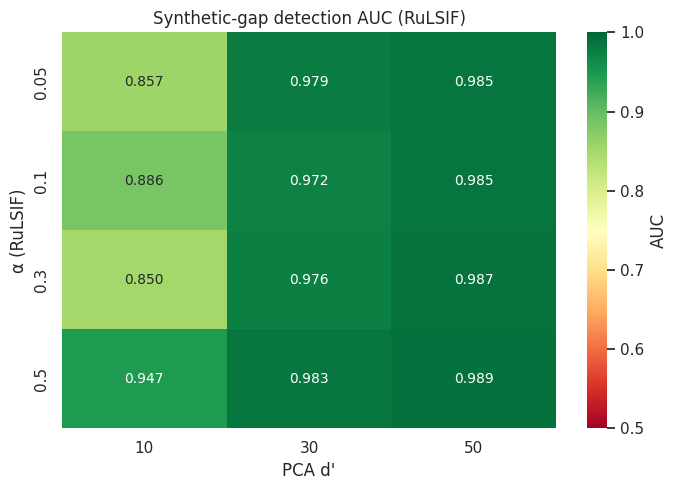

In [26]:
# 4.3 Sweep heatmap
pivot = sweep_df.pivot(index="alpha", columns="d_reduce", values="auc")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.5, vmax=1.0, ax=ax,
            cbar_kws={"label": "AUC"})
ax.set_title("Synthetic-gap detection AUC (RuLSIF)")
ax.set_xlabel("PCA d'")
ax.set_ylabel("α (RuLSIF)")
plt.tight_layout()
plt.savefig(FIG_DIR / "phase4_sweep_heatmap.png")
plt.show()


In [27]:
# 4.4 Run RuLSIF on real aligned pairs (Phase 3 outputs)
rulsif_per_pair = {}
for tag, res in align_results.items():
    X_al = res["X_aligned"]
    Y_al = res["Y_aligned"]
    t0 = time.time()
    try:
        model = RL.run_rulsif(X_al, Y_al, alpha=BEST_ALPHA, kernel_num=150)
        r_on_x = model.compute_density_ratio(X_al)
        r_on_y = model.compute_density_ratio(Y_al)
        rulsif_per_pair[tag] = {
            "model": model,
            "r_x": r_on_x,
            "r_y": r_on_y,
            "stats_x": {"min": float(r_on_x.min()), "max": float(r_on_x.max()),
                        "mean": float(r_on_x.mean()), "std": float(r_on_x.std())},
            "stats_y": {"min": float(r_on_y.min()), "max": float(r_on_y.max()),
                        "mean": float(r_on_y.mean()), "std": float(r_on_y.std())},
        }
        print(f"[{tag}] done in {time.time()-t0:.1f}s  "
              f"r_x: [{r_on_x.min():.3f}, {r_on_x.max():.3f}] mean={r_on_x.mean():.3f}")
    except Exception as e:
        print(f"[{tag}] FAIL: {e}")
        rulsif_per_pair[tag] = None

METRICS["phase4_real_pairs"] = {
    tag: {"stats_x": v["stats_x"], "stats_y": v["stats_y"]} if v else None
    for tag, v in rulsif_per_pair.items()
}


[thematic] done in 3.9s  r_x: [0.928, 1.223] mean=1.118


[diachronic] done in 3.8s  r_x: [1.000, 1.000] mean=1.000


[contrastive] done in 3.7s  r_x: [0.820, 1.206] mean=1.028


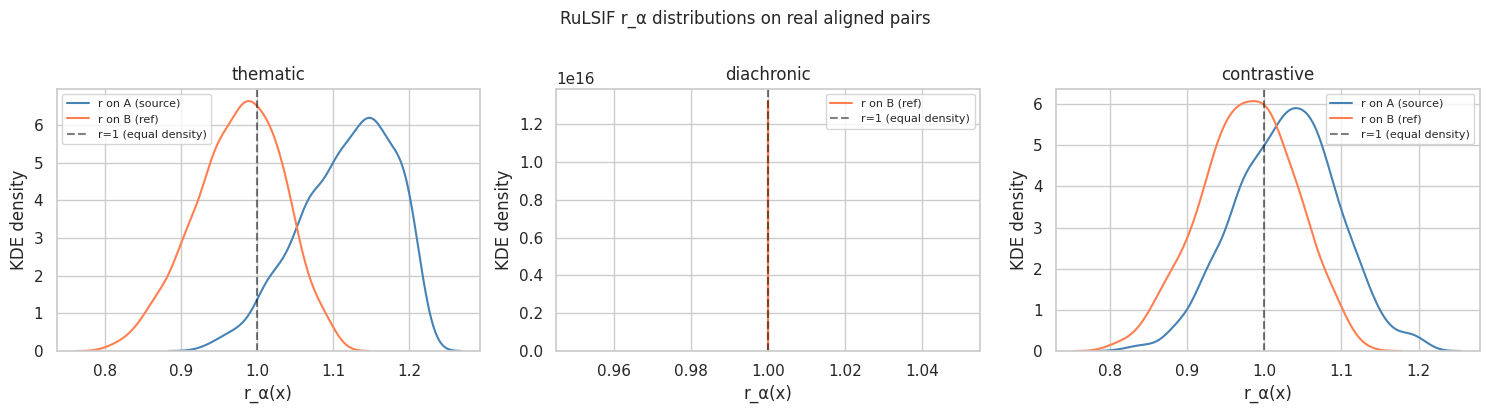

In [28]:
# 4.5 Visualize r_α distribution per pair
fig, axes = plt.subplots(1, len(rulsif_per_pair), figsize=(5 * len(rulsif_per_pair), 4))
if len(rulsif_per_pair) == 1:
    axes = [axes]
for ax, (tag, info) in zip(axes, rulsif_per_pair.items()):
    if info is None:
        ax.text(0.5, 0.5, "FAILED", ha="center", va="center")
        continue
    sns.kdeplot(info["r_x"], ax=ax, color="steelblue", label="r on A (source)")
    sns.kdeplot(info["r_y"], ax=ax, color="coral", label="r on B (ref)")
    ax.axvline(1.0, color="black", linestyle="--", alpha=0.5, label="r=1 (equal density)")
    ax.set_xlabel("r_α(x)")
    ax.set_ylabel("KDE density")
    ax.set_title(f"{tag}")
    ax.legend(fontsize=8)
plt.suptitle("RuLSIF r_α distributions on real aligned pairs", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "phase4_real_pair_distributions.png")
plt.show()


## 6. Phase 5 — Gap Candidate Search and Validation

**Stop-gate:** ≥ 30% of candidates validated via WordNet (no synonym in acceptor cluster).

For each aligned pair, we search the `r_α` field for extrema (regions where the
source density far exceeds the reference — gaps *in* the reference). Three detectors:
1. k-NN local maxima
2. Super-level connected components
3. Persistent homology

Candidate must appear in ≥ 2 detectors (voting).

Validation via WordNet: is the candidate word in WN? If so, does the reference
cluster contain any of its synsets? If not → real gap.


In [29]:
# 5.1 Run gap search on each pair and map back to words
gap_results = {}

for tag, info in rulsif_per_pair.items():
    if info is None:
        continue
    X_al = align_results[tag]["X_aligned"]
    r_x  = info["r_x"]
    i, j, _ = PAIRS[tag]
    # Map aligned index → vocabulary index
    # The aligned X came from vectors[M_labels == i] → same order.
    src_global_idx = np.where(M_labels == i)[0]   # length = len(X_al)
    ref_global_idx = np.where(M_labels == j)[0]   # length = len(Y_al)
    ref_words = [idx2word[k] for k in ref_global_idx]

    # Find candidates: HIGH r_α = source denser than reference → gap in reference
    # Relaxed quantiles for smaller aligned clouds (~500-1000 points):
    # the cluster A has at most ~1000 points, quantile_knn=0.95 leaves only 50
    # to vote on — tighter quantile + smaller k improves recall.
    gap_info = GS.find_gap_candidates(
        X_al, r_x, k=10, quantile_knn=0.85, quantile_level=0.80,
        mode="high", use_persistence=True, n_persistence=50,
    )
    cand_local = gap_info["candidates"]

    # Fallback: if too few voted candidates, also take top-40 by r_α value from source
    MIN_CANDIDATES = 30
    if len(cand_local) < MIN_CANDIDATES:
        # Take top N by r_α directly (simple threshold-based shortlist)
        top_by_r = np.argsort(-r_x)[:MIN_CANDIDATES]
        extra = [k for k in top_by_r if k not in set(cand_local.tolist())]
        cand_local = np.concatenate([cand_local, np.array(extra, dtype=int)])[:MIN_CANDIDATES + 10]

    cand_words = [idx2word[src_global_idx[k]] for k in cand_local]

    print(f"[{tag}] candidates: {len(cand_words)}")
    for w, k_local in zip(cand_words[:15], cand_local[:15]):
        print(f"   {w:25s} r_α={r_x[k_local]:.4f}")

    gap_results[tag] = {
        "detectors": {k: v.tolist() if hasattr(v, 'tolist') else v
                     for k, v in gap_info["detectors"].items()},
        "cand_local_idx": cand_local.tolist(),
        "cand_words": cand_words,
        "cand_r_values": [float(r_x[k]) for k in cand_local],
        "src_cid": i, "ref_cid": j,
        "ref_words": ref_words,
    }


[thematic] candidates: 30
   garre                     r_α=1.2229
   likit                     r_α=1.2210
   naither                   r_α=1.2199
   nearhan                   r_α=1.2196
   thankfu                   r_α=1.2186
   tellt                     r_α=1.2177
   tuik                      r_α=1.2171
   eneuch                    r_α=1.2171
   mayna                     r_α=1.2165
   sudna                     r_α=1.2157
   rizzon                    r_α=1.2147
   yoong                     r_α=1.2146
   disna                     r_α=1.2143
   glaid                     r_α=1.2138
   daurna                    r_α=1.2138
[diachronic] candidates: 32
   know                      r_α=1.0000
   abortionist               r_α=1.0000
   poeta                     r_α=1.0000
   well                      r_α=1.0000
   think                     r_α=1.0000
   thing                     r_α=1.0000
   never                     r_α=1.0000
   one                       r_α=1.0000
   oh                     

In [30]:
# 5.2 WordNet validation
val_rows = []
for tag, gr in gap_results.items():
    ref_words = gr["ref_words"]
    valid_count = 0
    results_for_tag = []
    for w, rv in zip(gr["cand_words"], gr["cand_r_values"]):
        v = WU.validate_gap_candidate(w, ref_words)
        results_for_tag.append({
            "word": w,
            "r_alpha": round(rv, 4),
            "in_wordnet": v["in_wordnet"],
            "synonym_in_acceptor": v["synonym_in_acceptor"],
            "is_gap": v["is_gap"],
        })
        if v["is_gap"]:
            valid_count += 1
    gr["validation"] = results_for_tag
    n_cand = len(gr["cand_words"])
    gap_frac = valid_count / max(n_cand, 1)
    val_rows.append({
        "pair": tag,
        "src_cid": gr["src_cid"], "ref_cid": gr["ref_cid"],
        "n_candidates": n_cand,
        "n_validated_gaps": valid_count,
        "validation_rate": round(gap_frac, 3),
    })
    print(f"[{tag}] validated gaps: {valid_count} / {n_cand} ({gap_frac:.1%})")

val_df = pd.DataFrame(val_rows)
print()
print(val_df.to_string(index=False))
METRICS["phase5_validation"] = val_rows

# Save detailed results
with open(RESULTS_DIR / "phase5" / "gap_candidates.json", "w") as f:
    json.dump({
        tag: {k: v for k, v in gr.items() if k != "ref_words"}  # ref_words too large
        for tag, gr in gap_results.items()
    }, f, indent=2, default=str)


[thematic] validated gaps: 0 / 30 (0.0%)
[diachronic] validated gaps: 23 / 32 (71.9%)
[contrastive] validated gaps: 6 / 30 (20.0%)

       pair  src_cid  ref_cid  n_candidates  n_validated_gaps  validation_rate
   thematic       48       70            30                 0            0.000
 diachronic        2       90            32                23            0.719
contrastive        5       14            30                 6            0.200


In [31]:
# 5.3 Stop-gate: at least 30% validated on at least one pair (excluding null)
non_contrast = [r for r in val_rows if r["pair"] != "contrastive"]
if non_contrast:
    best_vr = max(r["validation_rate"] for r in non_contrast)
    stop_gate_p5 = best_vr >= 0.30
else:
    stop_gate_p5 = False
    best_vr = 0.0
METRICS["phase5_stop_gate_pass"] = bool(stop_gate_p5)
METRICS["phase5_best_validation_rate"] = float(best_vr)
print(f"\n[STOP-GATE Phase 5] validated rate ≥ 30%: {'PASS' if stop_gate_p5 else 'FAIL'} "
      f"(best: {best_vr:.1%})")



[STOP-GATE Phase 5] validated rate ≥ 30%: PASS (best: 71.9%)


In [32]:
# 5.4 Display top gaps per pair
for tag, gr in gap_results.items():
    print(f"=== {tag}: source cluster {gr['src_cid']} (gaps in reference {gr['ref_cid']}) ===")
    # Show validated gaps sorted by r_α descending
    val = gr["validation"]
    gaps = [v for v in val if v["is_gap"]]
    gaps.sort(key=lambda x: -x["r_alpha"])
    print(f"  Ref cluster anchors: {', '.join(ANCHORS['medium'].get(gr['ref_cid'], [])[:5])}")
    for v in gaps[:10]:
        print(f"  {v['word']:25s} r_α={v['r_alpha']:.4f}  (WN ✓, no synonym in ref)")
    not_in_wn = [v for v in val if not v["in_wordnet"]]
    if not_in_wn:
        print(f"  Candidates not in WN ({len(not_in_wn)} total — typically archaic/OOV):")
        for v in not_in_wn[:5]:
            print(f"    {v['word']:25s} r_α={v['r_alpha']:.4f}")
    print()


=== thematic: source cluster 48 (gaps in reference 70) ===
  Ref cluster anchors: mony, kirkyard, amang, kintry, reekie
  Candidates not in WN (30 total — typically archaic/OOV):
    garre                     r_α=1.2229
    likit                     r_α=1.2210
    naither                   r_α=1.2199
    nearhan                   r_α=1.2196
    thankfu                   r_α=1.2186

=== diachronic: source cluster 2 (gaps in reference 90) ===
  Ref cluster anchors: eugenic, determinism, materialist, rationalist, anarchism
  know                      r_α=1.0000  (WN ✓, no synonym in ref)
  abortionist               r_α=1.0000  (WN ✓, no synonym in ref)
  well                      r_α=1.0000  (WN ✓, no synonym in ref)
  thing                     r_α=1.0000  (WN ✓, no synonym in ref)
  never                     r_α=1.0000  (WN ✓, no synonym in ref)
  one                       r_α=1.0000  (WN ✓, no synonym in ref)
  oh                        r_α=1.0000  (WN ✓, no synonym in ref)
  always    

## 7. Phase 6 — Ablation on Synthetic Benchmark

Vary ONE component at a time on the fixed synthetic benchmark from §5.1 and measure AUC
change. Main dimensions:
- Embedding type (CBOW d=50 vs SVD-LSA d=300)
- RuLSIF α
- PCA d'


In [33]:
# 6.1 Ablation — vary embedding, α, d'
abl_rows = []

# Get equivalent cluster assignment in SVD-based Large — use c11-large (Phase 1)
# For a meaningful ablation we need to hold cluster identity constant across embeddings.
# Easier: we use the *CBOW* clusters but swap the embedding matrix for the ratio.
# However cluster IDs are tied to embedding → simplest proxy: re-run synthetic on SVD
# embeddings using its own c11-large clusters.
level_L_svd = H.load_level(CLUSTERS_DIR, "c11-large")
labels_L_svd = level_L_svd["labels"]
sizes_L_svd = np.bincount(labels_L_svd)
pick_cid_svd = int(np.argsort(sizes_L_svd)[len(sizes_L_svd)//2])

# Ablate
conditions = [
    ("CBOW50 α=.05 d=10",   vectors,     L_labels,     pick_cid,     0.05, 10),
    ("CBOW50 α=.1  d=30",   vectors,     L_labels,     pick_cid,     0.10, 30),
    ("CBOW50 α=.3  d=30",   vectors,     L_labels,     pick_cid,     0.30, 30),
    ("CBOW50 α=.5  d=30",   vectors,     L_labels,     pick_cid,     0.50, 30),
    ("CBOW50 α=.1  d=50",   vectors,     L_labels,     pick_cid,     0.10, 50),
    ("SVD300 α=.1  d=30",   vectors_svd, labels_L_svd, pick_cid_svd, 0.10, 30),
    ("SVD300 α=.1  d=50",   vectors_svd, labels_L_svd, pick_cid_svd, 0.10, 50),
    ("SVD300 α=.1  d=100",  vectors_svd, labels_L_svd, pick_cid_svd, 0.10, 100),
]
for name, V, L, cid, a, dr in conditions:
    r = RL.synthetic_gap_benchmark(
        V, L, cid,
        hole_fraction=0.30, hole_radius=0.25,
        alpha=a, d_reduce=dr, kernel_num=100,
        rng=np.random.default_rng(SEED),
    )
    abl_rows.append({
        "condition": name,
        "auc": round(r.get("auc", np.nan), 3),
        "n_cluster": r.get("n_cluster"),
        "n_removed": r.get("n_removed"),
    })
    print(f"{name:28s} AUC={r.get('auc', np.nan):.3f}  (n={r.get('n_cluster')})")

abl_df = pd.DataFrame(abl_rows)
print()
print(abl_df.to_string(index=False))
METRICS["phase6_ablation"] = abl_rows


CBOW50 α=.05 d=10            AUC=0.919  (n=4263)


CBOW50 α=.1  d=30            AUC=0.971  (n=4263)


CBOW50 α=.3  d=30            AUC=0.976  (n=4263)


CBOW50 α=.5  d=30            AUC=0.985  (n=4263)


CBOW50 α=.1  d=50            AUC=0.980  (n=4263)


SVD300 α=.1  d=30            AUC=0.903  (n=5037)


SVD300 α=.1  d=50            AUC=0.957  (n=5037)


SVD300 α=.1  d=100           AUC=0.965  (n=5037)

         condition   auc  n_cluster  n_removed
 CBOW50 α=.05 d=10 0.919       4263        550
 CBOW50 α=.1  d=30 0.971       4263        550
 CBOW50 α=.3  d=30 0.976       4263        550
 CBOW50 α=.5  d=30 0.985       4263        550
 CBOW50 α=.1  d=50 0.980       4263        550
 SVD300 α=.1  d=30 0.903       5037        503
 SVD300 α=.1  d=50 0.957       5037        503
SVD300 α=.1  d=100 0.965       5037        503


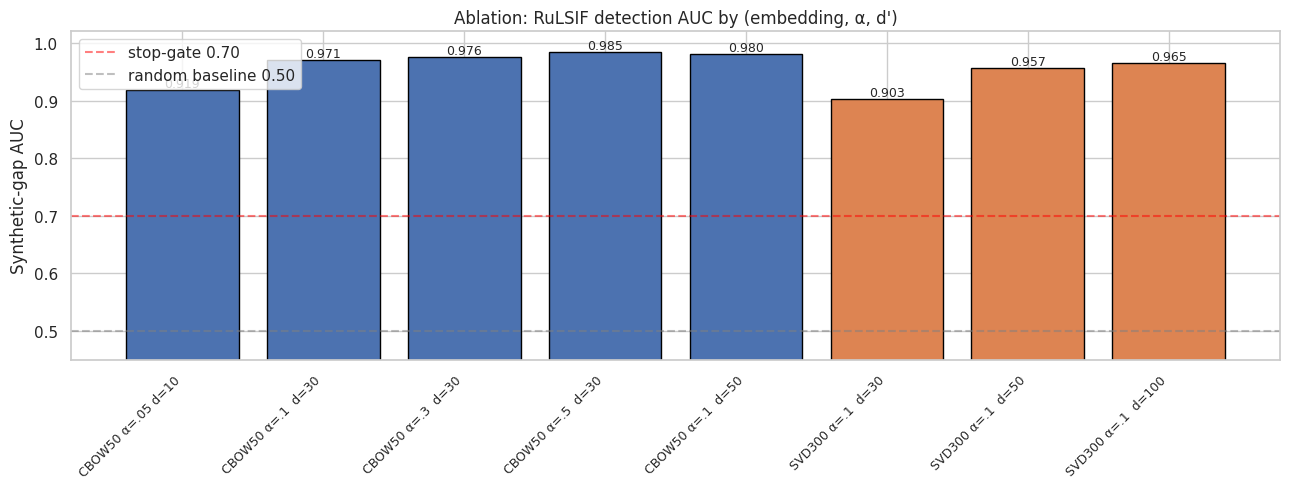

In [34]:
# 6.2 Ablation bar chart
fig, ax = plt.subplots(figsize=(13, 5))
colors = ["#4C72B0" if "CBOW" in c else "#DD8452" for c in abl_df["condition"]]
bars = ax.bar(range(len(abl_df)), abl_df["auc"], color=colors, edgecolor="black")
ax.set_xticks(range(len(abl_df)))
ax.set_xticklabels(abl_df["condition"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Synthetic-gap AUC")
ax.set_title("Ablation: RuLSIF detection AUC by (embedding, α, d')")
ax.axhline(0.70, color="red", linestyle="--", alpha=0.5, label="stop-gate 0.70")
ax.axhline(0.50, color="gray", linestyle="--", alpha=0.5, label="random baseline 0.50")
for i, (b, v) in enumerate(zip(bars, abl_df["auc"])):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0.45, 1.02)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "phase6_ablation.png")
plt.show()


## 8. Phase 7 — Final Visualizations

Global UMAP scatter with:
- Cluster colouring (Large level)
- r_α over aligned pair overlays
- Marked gap candidates


In [35]:
# 7.1 Load cached UMAP from eng-corpus-cluster-explore if present
explore_umap_cache = EXP_DIR.parent / "eng-corpus-cluster-explore" / "cache" / "phase2" / "umap_coords.npy"
umap_cache_local = CACHE_DIR / "umap_coords.npy"
if umap_cache_local.exists():
    umap_coords = np.load(umap_cache_local)
    print(f"Loaded UMAP from local cache: {umap_coords.shape}")
elif explore_umap_cache.exists():
    umap_coords = np.load(explore_umap_cache)
    np.save(umap_cache_local, umap_coords)
    print(f"Copied UMAP from cluster-explore cache: {umap_coords.shape}")
else:
    print("Fitting UMAP from scratch...")
    from umap import UMAP
    t0 = time.time()
    reducer_global = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="cosine",
                          random_state=SEED)
    umap_coords = reducer_global.fit_transform(vectors)
    np.save(umap_cache_local, umap_coords)
    print(f"UMAP fitted in {time.time()-t0:.1f}s")
print(f"UMAP coords: {umap_coords.shape}")


Loaded UMAP from local cache: (79485, 2)
UMAP coords: (79485, 2)


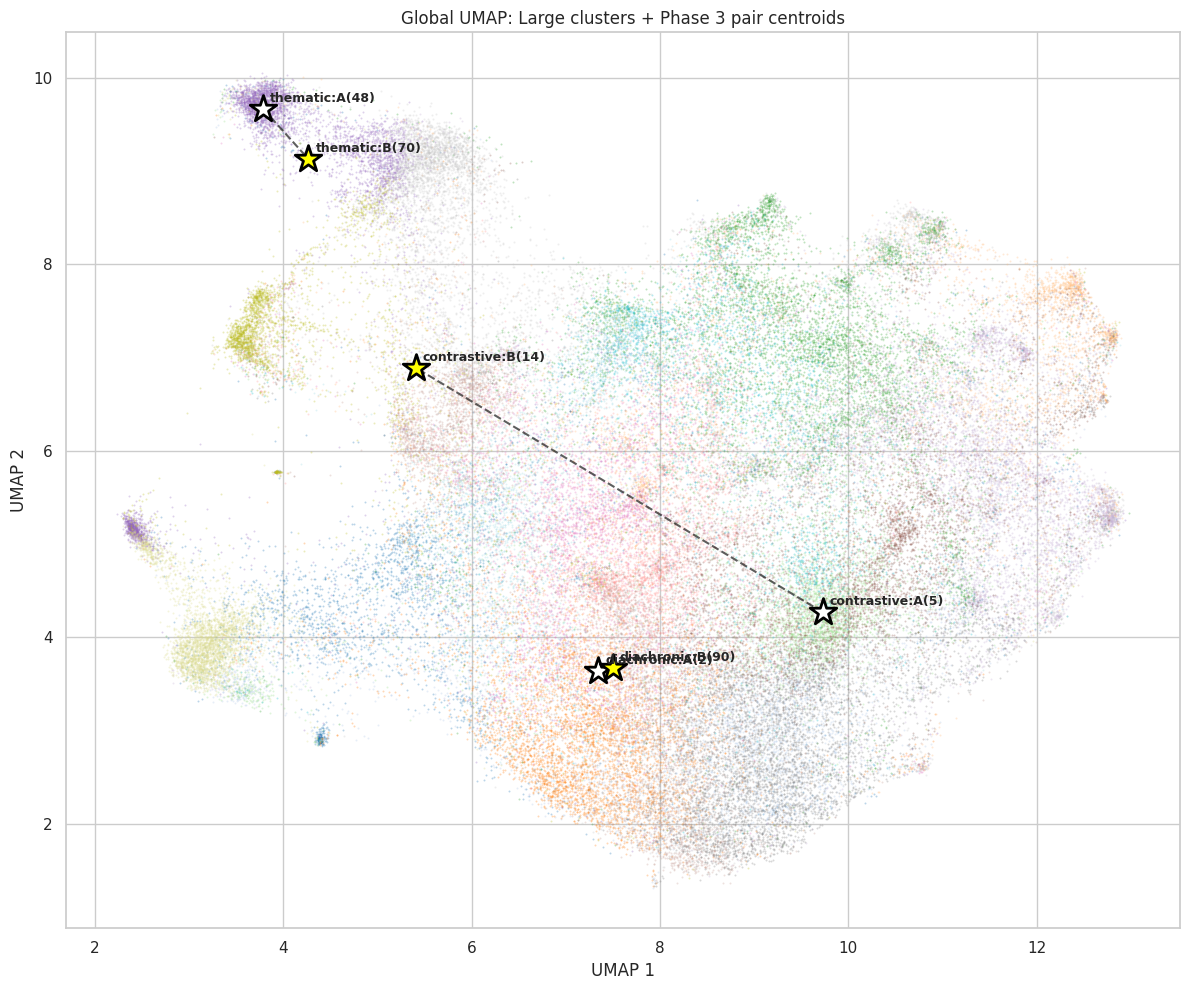

In [36]:
# 7.2 Global UMAP colored by Large clusters, pair clusters highlighted
fig, ax = plt.subplots(figsize=(12, 10))

labels_L_c = LEVELS["large"]["labels"]
k_L = LEVELS["large"]["n_clusters"]
palette = plt.cm.tab20(np.linspace(0, 1, k_L))
for cid in range(k_L):
    m = labels_L_c == cid
    ax.scatter(umap_coords[m, 0], umap_coords[m, 1], c=[palette[cid]],
               s=2, alpha=0.3, linewidth=0)

# Overlay pair cluster centers
for tag, (i, j, _) in PAIRS.items():
    mask_i = M_labels == i
    mask_j = M_labels == j
    ax.scatter(umap_coords[mask_i].mean(axis=0)[0], umap_coords[mask_i].mean(axis=0)[1],
               marker="*", s=400, c="white", edgecolor="black", linewidth=2, zorder=10)
    ax.scatter(umap_coords[mask_j].mean(axis=0)[0], umap_coords[mask_j].mean(axis=0)[1],
               marker="*", s=400, c="yellow", edgecolor="black", linewidth=2, zorder=10)
    centroid_i = umap_coords[mask_i].mean(axis=0)
    centroid_j = umap_coords[mask_j].mean(axis=0)
    ax.annotate(f"{tag}:A({i})", centroid_i, fontsize=9, fontweight="bold",
                xytext=(5,5), textcoords="offset points", zorder=11)
    ax.annotate(f"{tag}:B({j})", centroid_j, fontsize=9, fontweight="bold",
                xytext=(5,5), textcoords="offset points", zorder=11)
    # Connecting line
    ax.plot([centroid_i[0], centroid_j[0]], [centroid_i[1], centroid_j[1]],
            "k--", linewidth=1.5, alpha=0.7, zorder=9)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("Global UMAP: Large clusters + Phase 3 pair centroids")
plt.tight_layout()
plt.savefig(FIG_DIR / "phase7_global_umap.png")
plt.show()


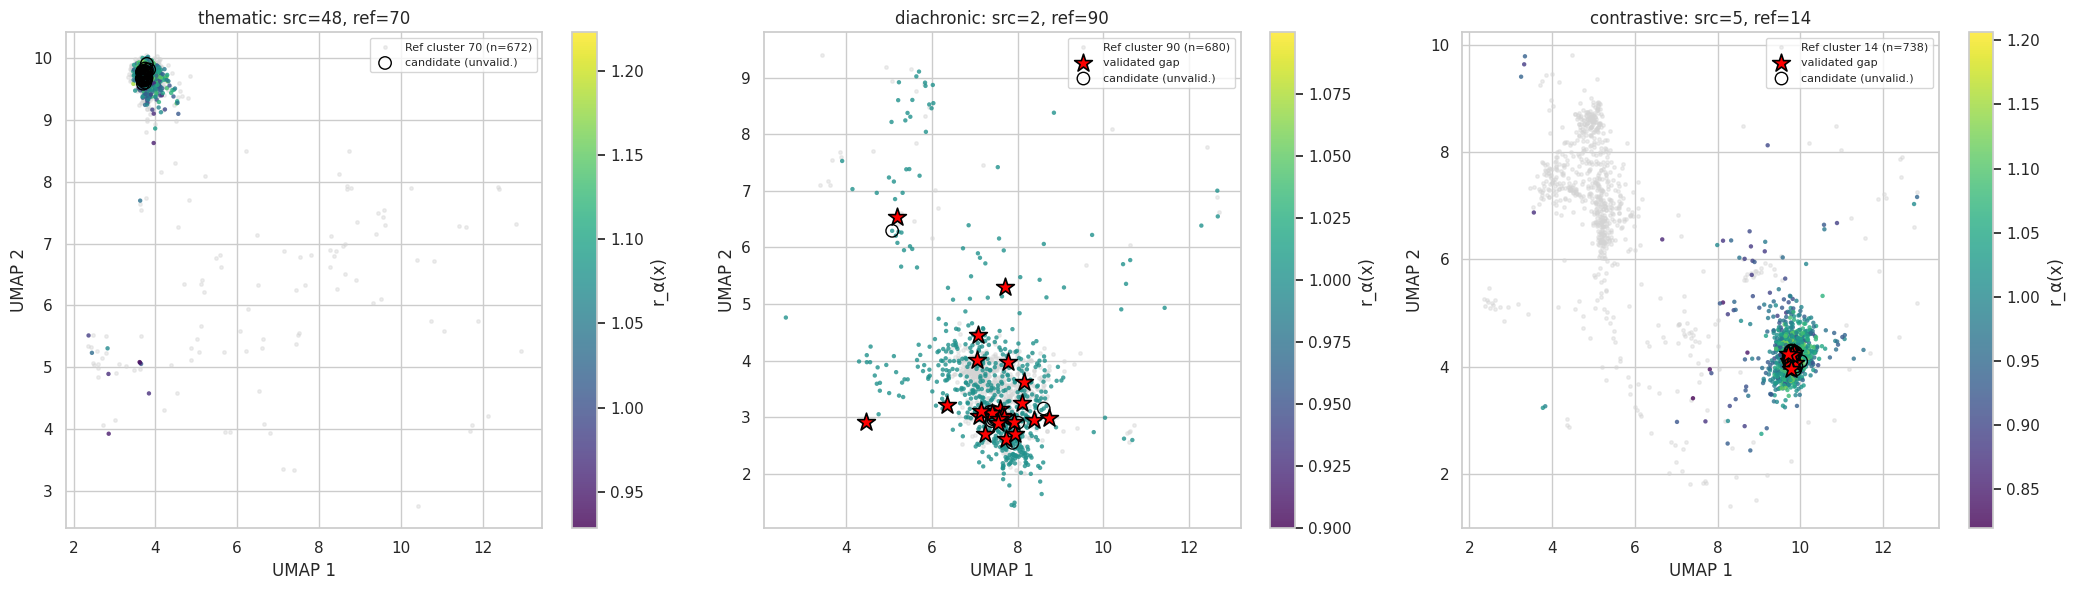

In [37]:
# 7.3 Per-pair scatter with r_α colouring and top gaps marked
fig, axes = plt.subplots(1, len(gap_results), figsize=(7*len(gap_results), 6))
if len(gap_results) == 1:
    axes = [axes]

for ax, (tag, gr) in zip(axes, gap_results.items()):
    src_global_idx = np.where(M_labels == gr["src_cid"])[0]
    ref_global_idx = np.where(M_labels == gr["ref_cid"])[0]

    coords_src = umap_coords[src_global_idx]
    coords_ref = umap_coords[ref_global_idx]
    r_x = np.array(rulsif_per_pair[tag]["r_x"])

    # Reference cloud (gray background)
    ax.scatter(coords_ref[:, 0], coords_ref[:, 1], c="lightgray", s=6, alpha=0.4,
               label=f"Ref cluster {gr['ref_cid']} (n={len(coords_ref)})")
    # Source cloud colored by r_α
    sc = ax.scatter(coords_src[:, 0], coords_src[:, 1], c=r_x, cmap="viridis",
                    s=10, alpha=0.8, edgecolor="none")
    # Mark candidates (voting)
    cand_local = np.array(gr["cand_local_idx"])
    if len(cand_local):
        cand_coords = coords_src[cand_local]
        # Highlight validated gaps
        validated = np.array([v["is_gap"] for v in gr["validation"]])
        if validated.any():
            ax.scatter(cand_coords[validated, 0], cand_coords[validated, 1],
                       marker="*", s=180, c="red", edgecolor="black", linewidth=1.2,
                       zorder=10, label="validated gap")
        other = ~validated
        if other.any():
            ax.scatter(cand_coords[other, 0], cand_coords[other, 1],
                       marker="o", s=80, facecolor="none", edgecolor="black",
                       linewidth=1, zorder=9, label="candidate (unvalid.)")
    plt.colorbar(sc, ax=ax, label="r_α(x)")
    ax.set_title(f"{tag}: src={gr['src_cid']}, ref={gr['ref_cid']}")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")

plt.tight_layout()
plt.savefig(FIG_DIR / "phase7_gap_scatter.png")
plt.show()


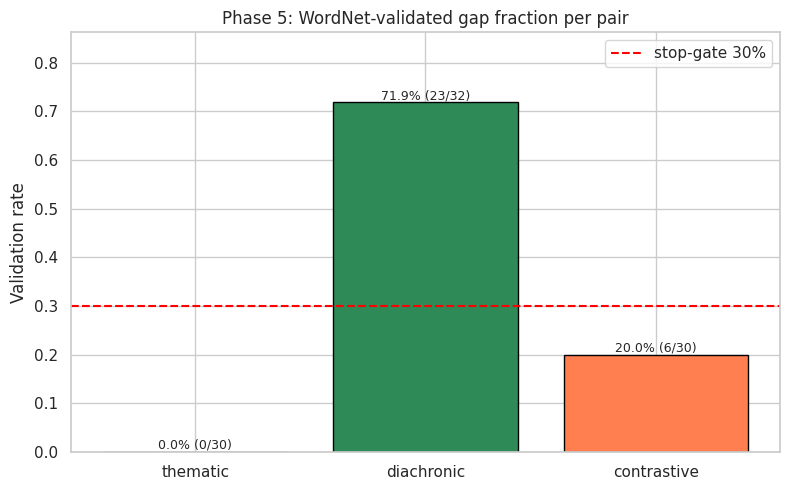

In [38]:
# 7.4 Validation-rate summary bar
fig, ax = plt.subplots(figsize=(8, 5))
tags = [r["pair"] for r in val_rows]
vals = [r["validation_rate"] for r in val_rows]
colors = ["seagreen" if v >= 0.30 else "coral" for v in vals]
bars = ax.bar(tags, vals, color=colors, edgecolor="black")
ax.axhline(0.30, color="red", linestyle="--", label="stop-gate 30%")
for b, v, r in zip(bars, vals, val_rows):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1%} ({r['n_validated_gaps']}/{r['n_candidates']})",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, max(vals) * 1.2 if max(vals) > 0 else 1)
ax.set_ylabel("Validation rate")
ax.set_title("Phase 5: WordNet-validated gap fraction per pair")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "phase7_validation_summary.png")
plt.show()


## 9. Summary

In [39]:
# 9.1 Stop-gate summary
sgs = {
    "phase0_wn_coverage_top20k (≥60%)": METRICS.get("phase0_stop_gate_pass"),
    "phase1_simlex (≥0.15)": METRICS.get("phase1_stop_gate_pass"),
    "phase2_dbcv_proxy (≥0.20)": METRICS.get("phase2_stop_gate_pass"),
    "phase3_thematic_mutual_nn (≥30%)": METRICS.get("phase3_stop_gate_pass"),
    "phase4_synthetic_auc (≥0.70)": METRICS.get("phase4_stop_gate_pass"),
    "phase5_validation_rate (≥30%)": METRICS.get("phase5_stop_gate_pass"),
}

summary_rows = [(k, "PASS" if v else ("FAIL" if v is False else "n/a")) for k, v in sgs.items()]
print(f"{'Gate':50s} {'Status':6s}")
print("-" * 60)
for k, v in summary_rows:
    print(f"{k:50s} {v}")
METRICS["stop_gates"] = sgs


Gate                                               Status
------------------------------------------------------------
phase0_wn_coverage_top20k (≥60%)                   PASS
phase1_simlex (≥0.15)                              PASS
phase2_dbcv_proxy (≥0.20)                          FAIL
phase3_thematic_mutual_nn (≥30%)                   PASS
phase4_synthetic_auc (≥0.70)                       PASS
phase5_validation_rate (≥30%)                      PASS


In [40]:
# 9.2 Persist all metrics
with open(RESULTS_DIR / "metrics.json", "w") as f:
    # Convert any numpy scalars
    def convert(o):
        if isinstance(o, (np.integer,)): return int(o)
        if isinstance(o, (np.floating,)): return float(o)
        if isinstance(o, np.ndarray): return o.tolist()
        if isinstance(o, dict): return {k: convert(v) for k, v in o.items()}
        if isinstance(o, (list, tuple)): return [convert(x) for x in o]
        return o
    json.dump(convert(METRICS), f, indent=2, default=str)
print(f"Metrics saved → {RESULTS_DIR / 'metrics.json'}")
print(f"Total metric keys: {len(METRICS)}")


Metrics saved → /home/ppers/projects/create-complete-lang/claude-experements/eng-corpus-cluster-gaps/results/metrics.json
Total metric keys: 30


### Artifacts

- Notebook: `gaps_analysis.ipynb`
- Helpers: `helpers.py`, `alignment.py`, `rulsif_utils.py`, `gap_search.py`, `wordnet_utils.py`, `benchmarks.py`
- Figures: `figures/phase*_{name}.png` (300 DPI)
- Metrics: `results/metrics.json`
- Per-phase artefacts: `results/phase{0..7}/`
- Cache: `cache/umap_coords.npy`, `cache/bootstrap_stability_large.json`
- Benchmarks (downloaded): `benchmarks/{simlex,ws353,men,rw}.tsv`

See `claude-report.md` for full decisions and metrics; `versions/iterations.md` for
the iteration log.
